# Import and Show the Data

In [521]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.metrics import confusion_matrix, roc_curve, auc, precision_recall_curve, classification_report
from sklearn.preprocessing import label_binarize
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import RFE, SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression, LassoCV
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.callbacks import EarlyStopping
from scikeras.wrappers import KerasClassifier
import time


# Import data
df = pd.read_csv("/Users/cocozhang/Desktop/Obesity prediction.csv")

df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Gender          2111 non-null   object 
 1   Age             2111 non-null   float64
 2   Height          2111 non-null   float64
 3   Weight          2111 non-null   float64
 4   family_history  2111 non-null   object 
 5   FAVC            2111 non-null   object 
 6   FCVC            2111 non-null   float64
 7   NCP             2111 non-null   float64
 8   CAEC            2111 non-null   object 
 9   SMOKE           2111 non-null   object 
 10  CH2O            2111 non-null   float64
 11  SCC             2111 non-null   object 
 12  FAF             2111 non-null   float64
 13  TUE             2111 non-null   float64
 14  CALC            2111 non-null   object 
 15  MTRANS          2111 non-null   object 
 16  Obesity         2111 non-null   object 
dtypes: float64(8), object(9)
memory u

,Gender,Age,Height,Weight,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,Obesity
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


# EDA

In [524]:

plt.style.use("ggplot")

# numerical and categorical features
numerical_features = df.select_dtypes(include=["float64"]).columns.tolist()
categorical_features = df.select_dtypes(include=["object"]).columns.tolist()
categorical_features.remove("Obesity")  # Remove target variable from categorical list

# Function to create histograms
def plot_histograms(df, numerical_features):
    for feature in numerical_features:
        plt.figure(figsize=(8, 4))
        sns.histplot(df[feature], bins=30, kde=True, color="royalblue")
        plt.title(f"Distribution of {feature}")
        plt.xlabel(feature)
        plt.ylabel("Count")
        plt.grid(True)
        plt.show()

# Function to create boxplots
def plot_boxplots(df, numerical_features, target_col="Obesity"):
    for feature in numerical_features:
        plt.figure(figsize=(8, 4))
        sns.boxplot(x=df[target_col], y=df[feature], hue=df[target_col], palette="coolwarm", legend=False)
        plt.xticks(rotation=45)
        plt.title(f"{feature} Distribution by {target_col}")
        plt.xlabel(target_col)
        plt.ylabel(feature)
        plt.grid(True)
        plt.show()

# Function to create count plots
def plot_categorical_counts(df, categorical_features):
    for feature in categorical_features:
        plt.figure(figsize=(4, 2))
        sns.countplot(x=df[feature], hue=df[feature], palette="viridis", order=df[feature].value_counts().index, legend=False)
        plt.title(f"Distribution of {feature}")
        plt.xlabel(feature)
        plt.ylabel("Count")
        plt.xticks(rotation=45)
        plt.grid(True)
        plt.show()

# Function to check feature correlations
def plot_correlation_matrix(df):
    plt.figure(figsize=(8, 6))
    corr_matrix = df.corr(numeric_only=True)
    sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
    plt.title("Feature Correlation Matrix")
    plt.show()

# Function to create pairplots
def plot_pairplot(df, numerical_features, target_col="Obesity"):
    try:
        sns.pairplot(df, vars=numerical_features, hue=target_col, palette="husl", diag_kind="kde")
        plt.show()
    except Exception as e:
        print(f"Error in pairplot: {e}")



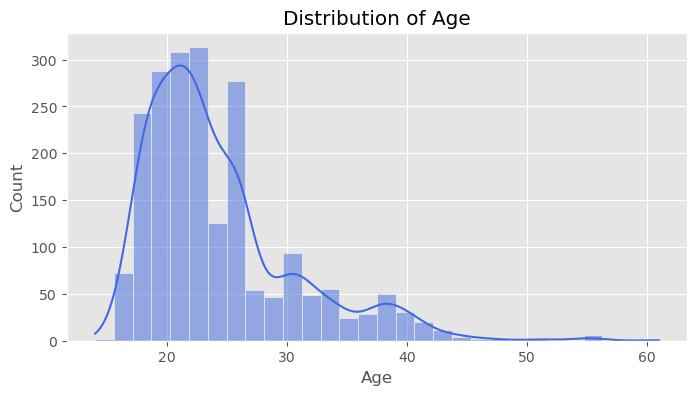

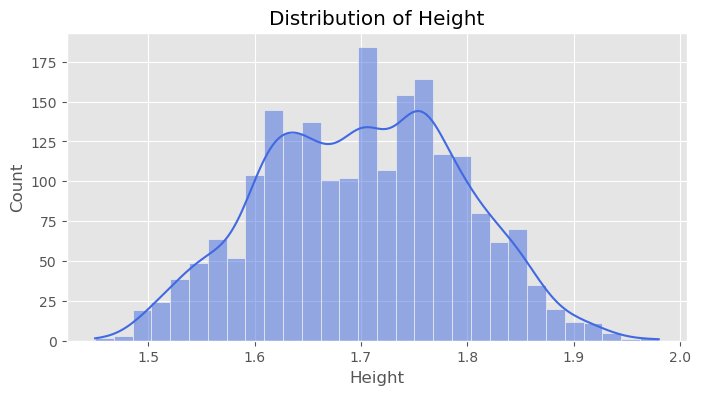

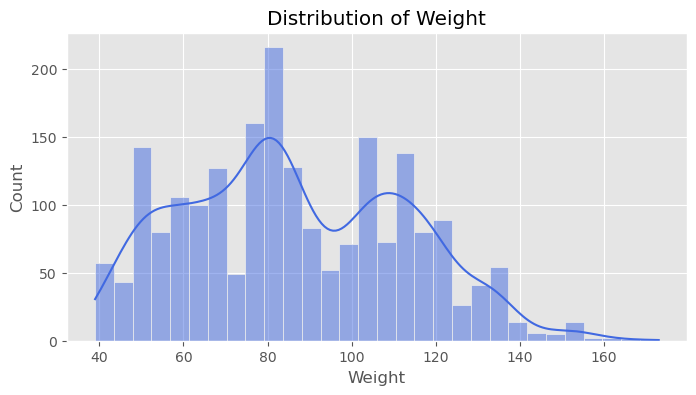

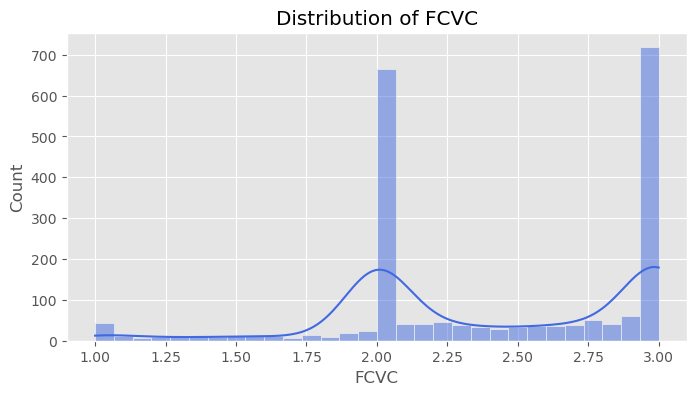

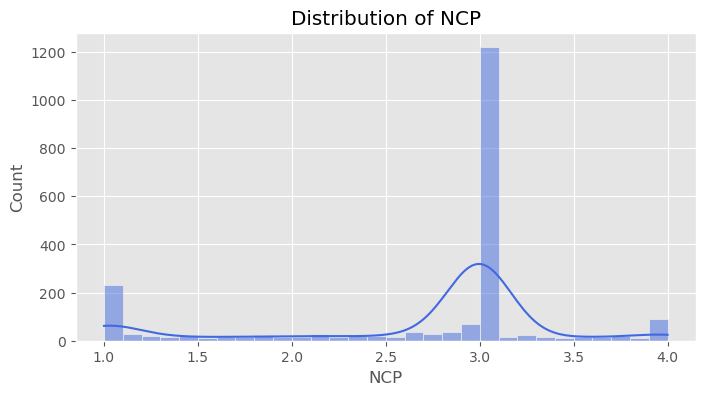

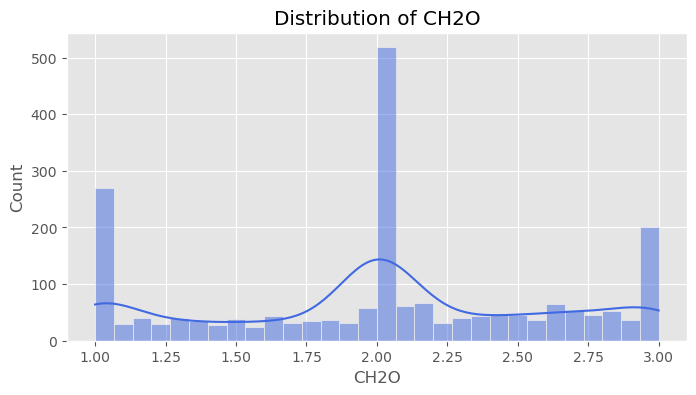

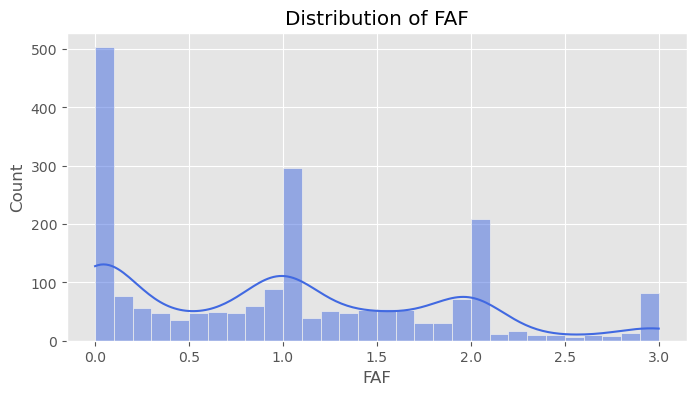

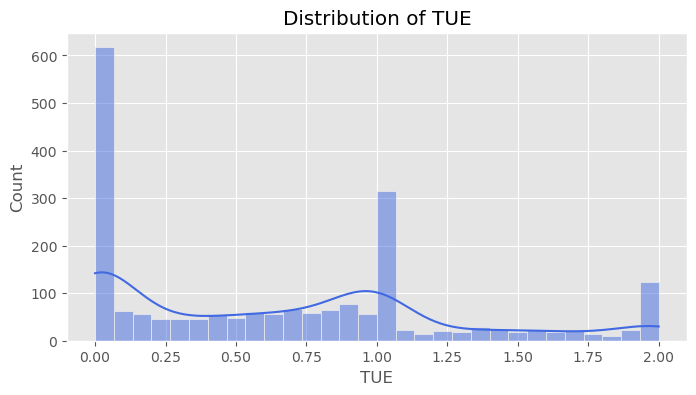

In [526]:
plot_histograms(df, numerical_features)

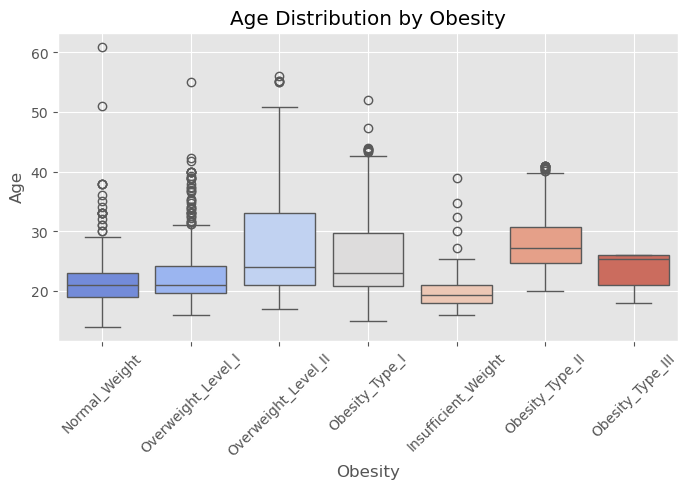

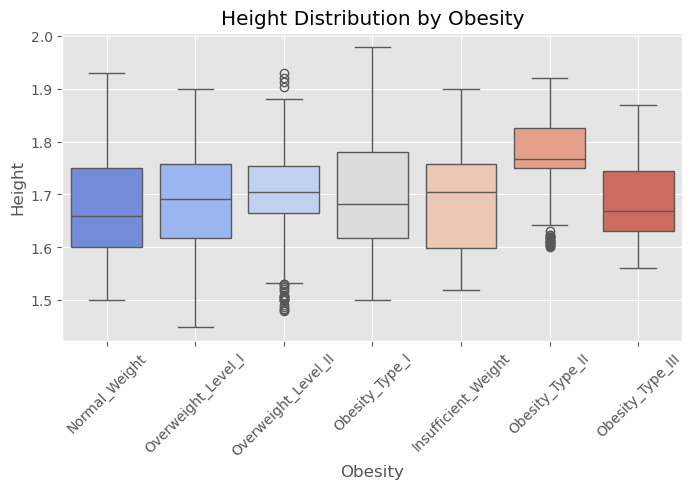

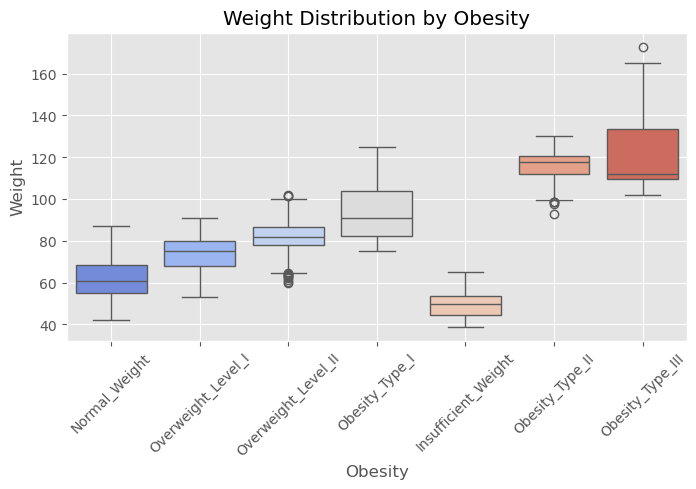

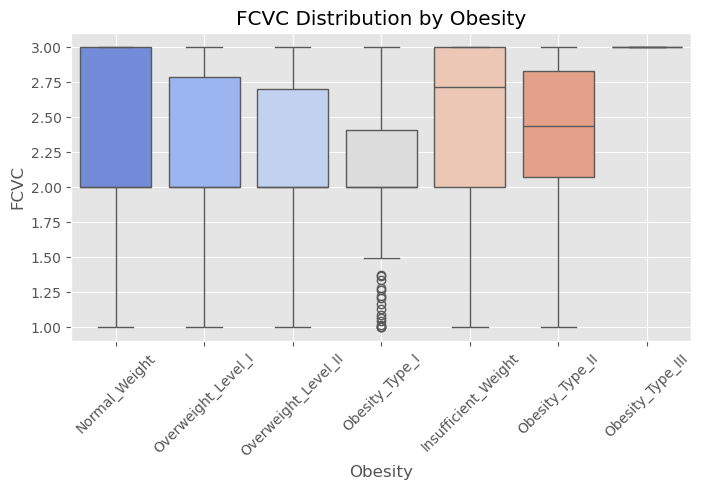

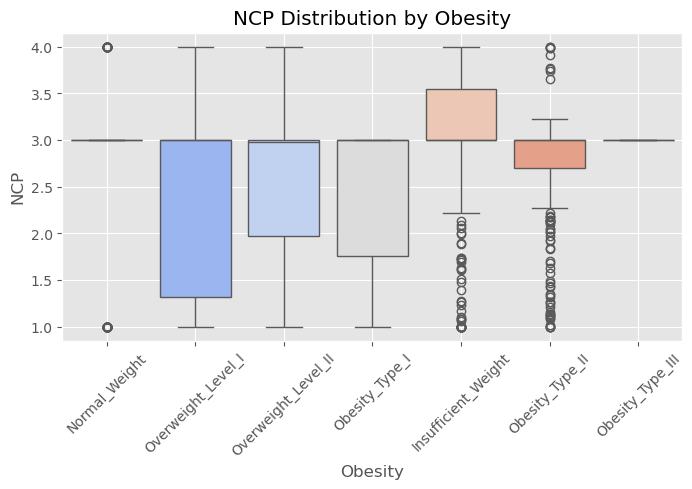

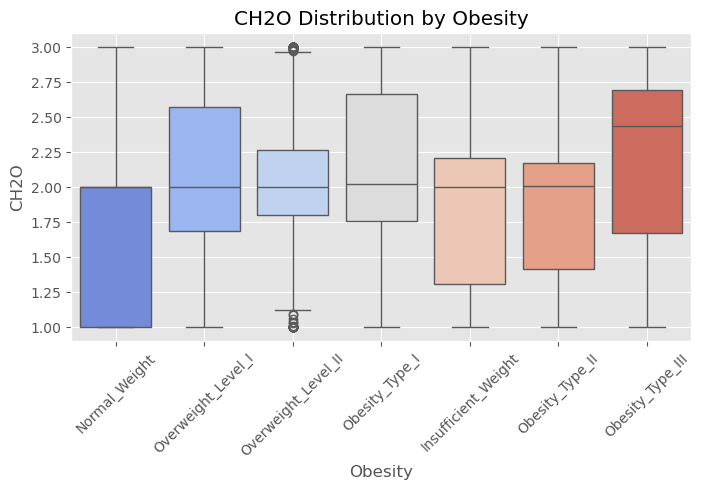

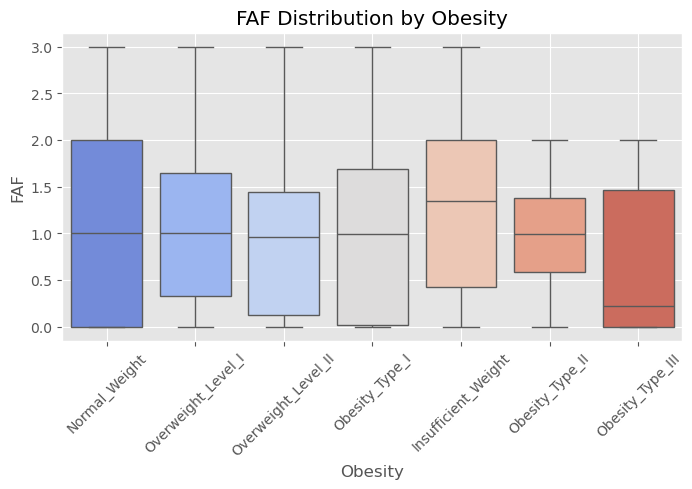

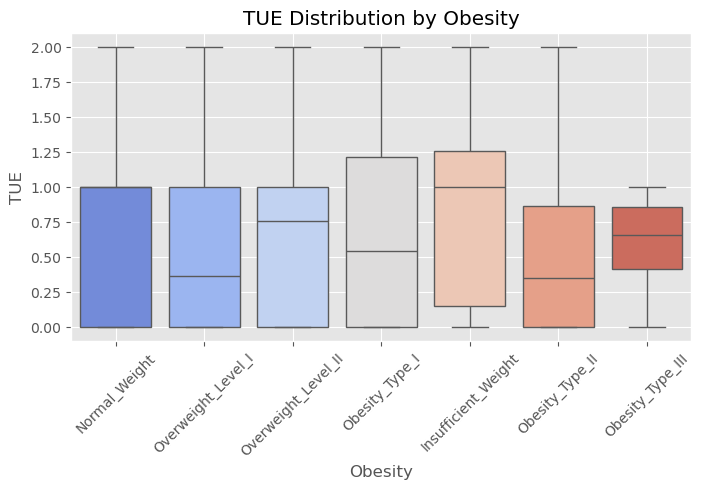

In [527]:
plot_boxplots(df, numerical_features)

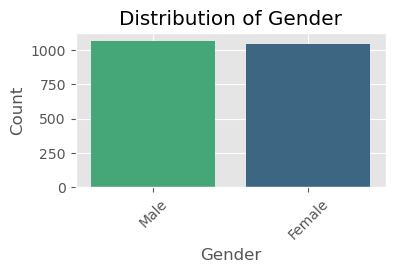

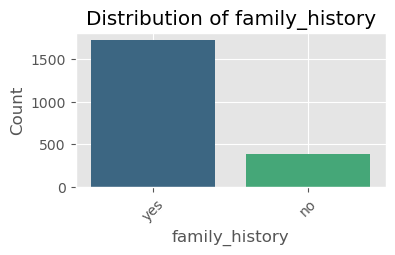

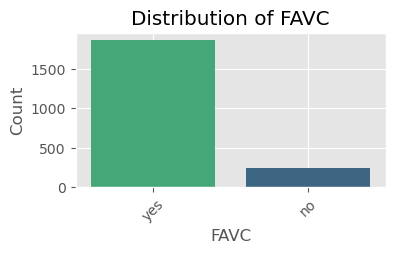

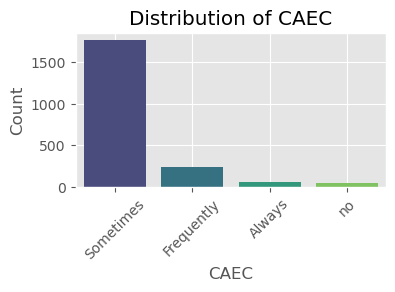

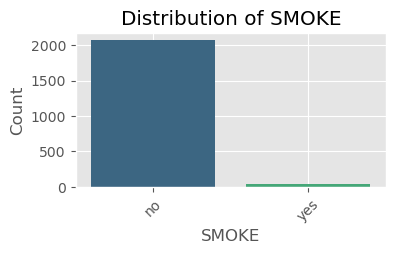

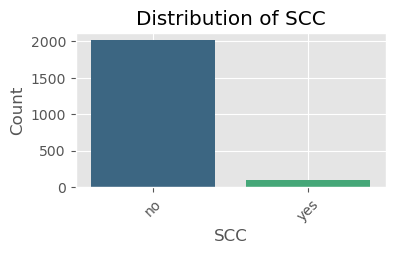

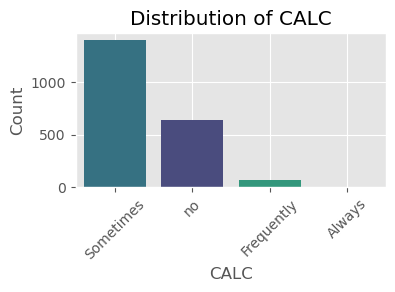

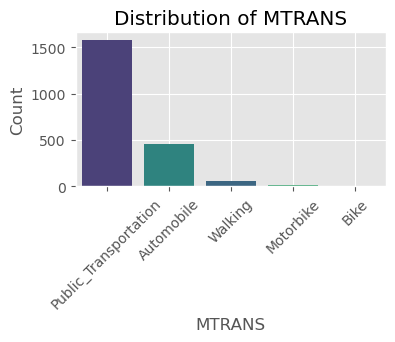

In [528]:
plot_categorical_counts(df, categorical_features)

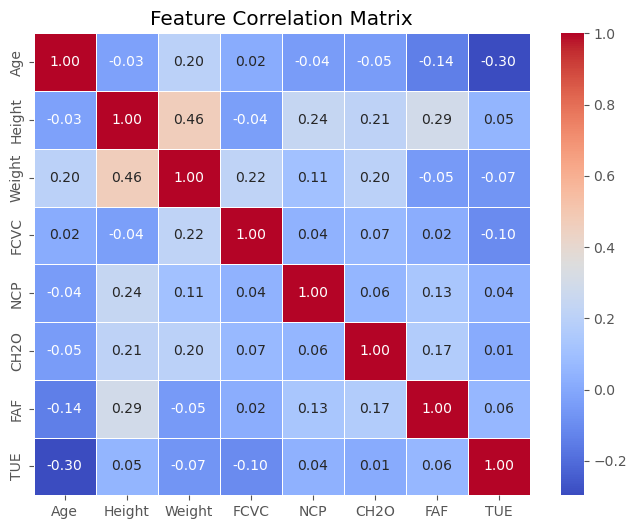

In [530]:
plot_correlation_matrix(df)

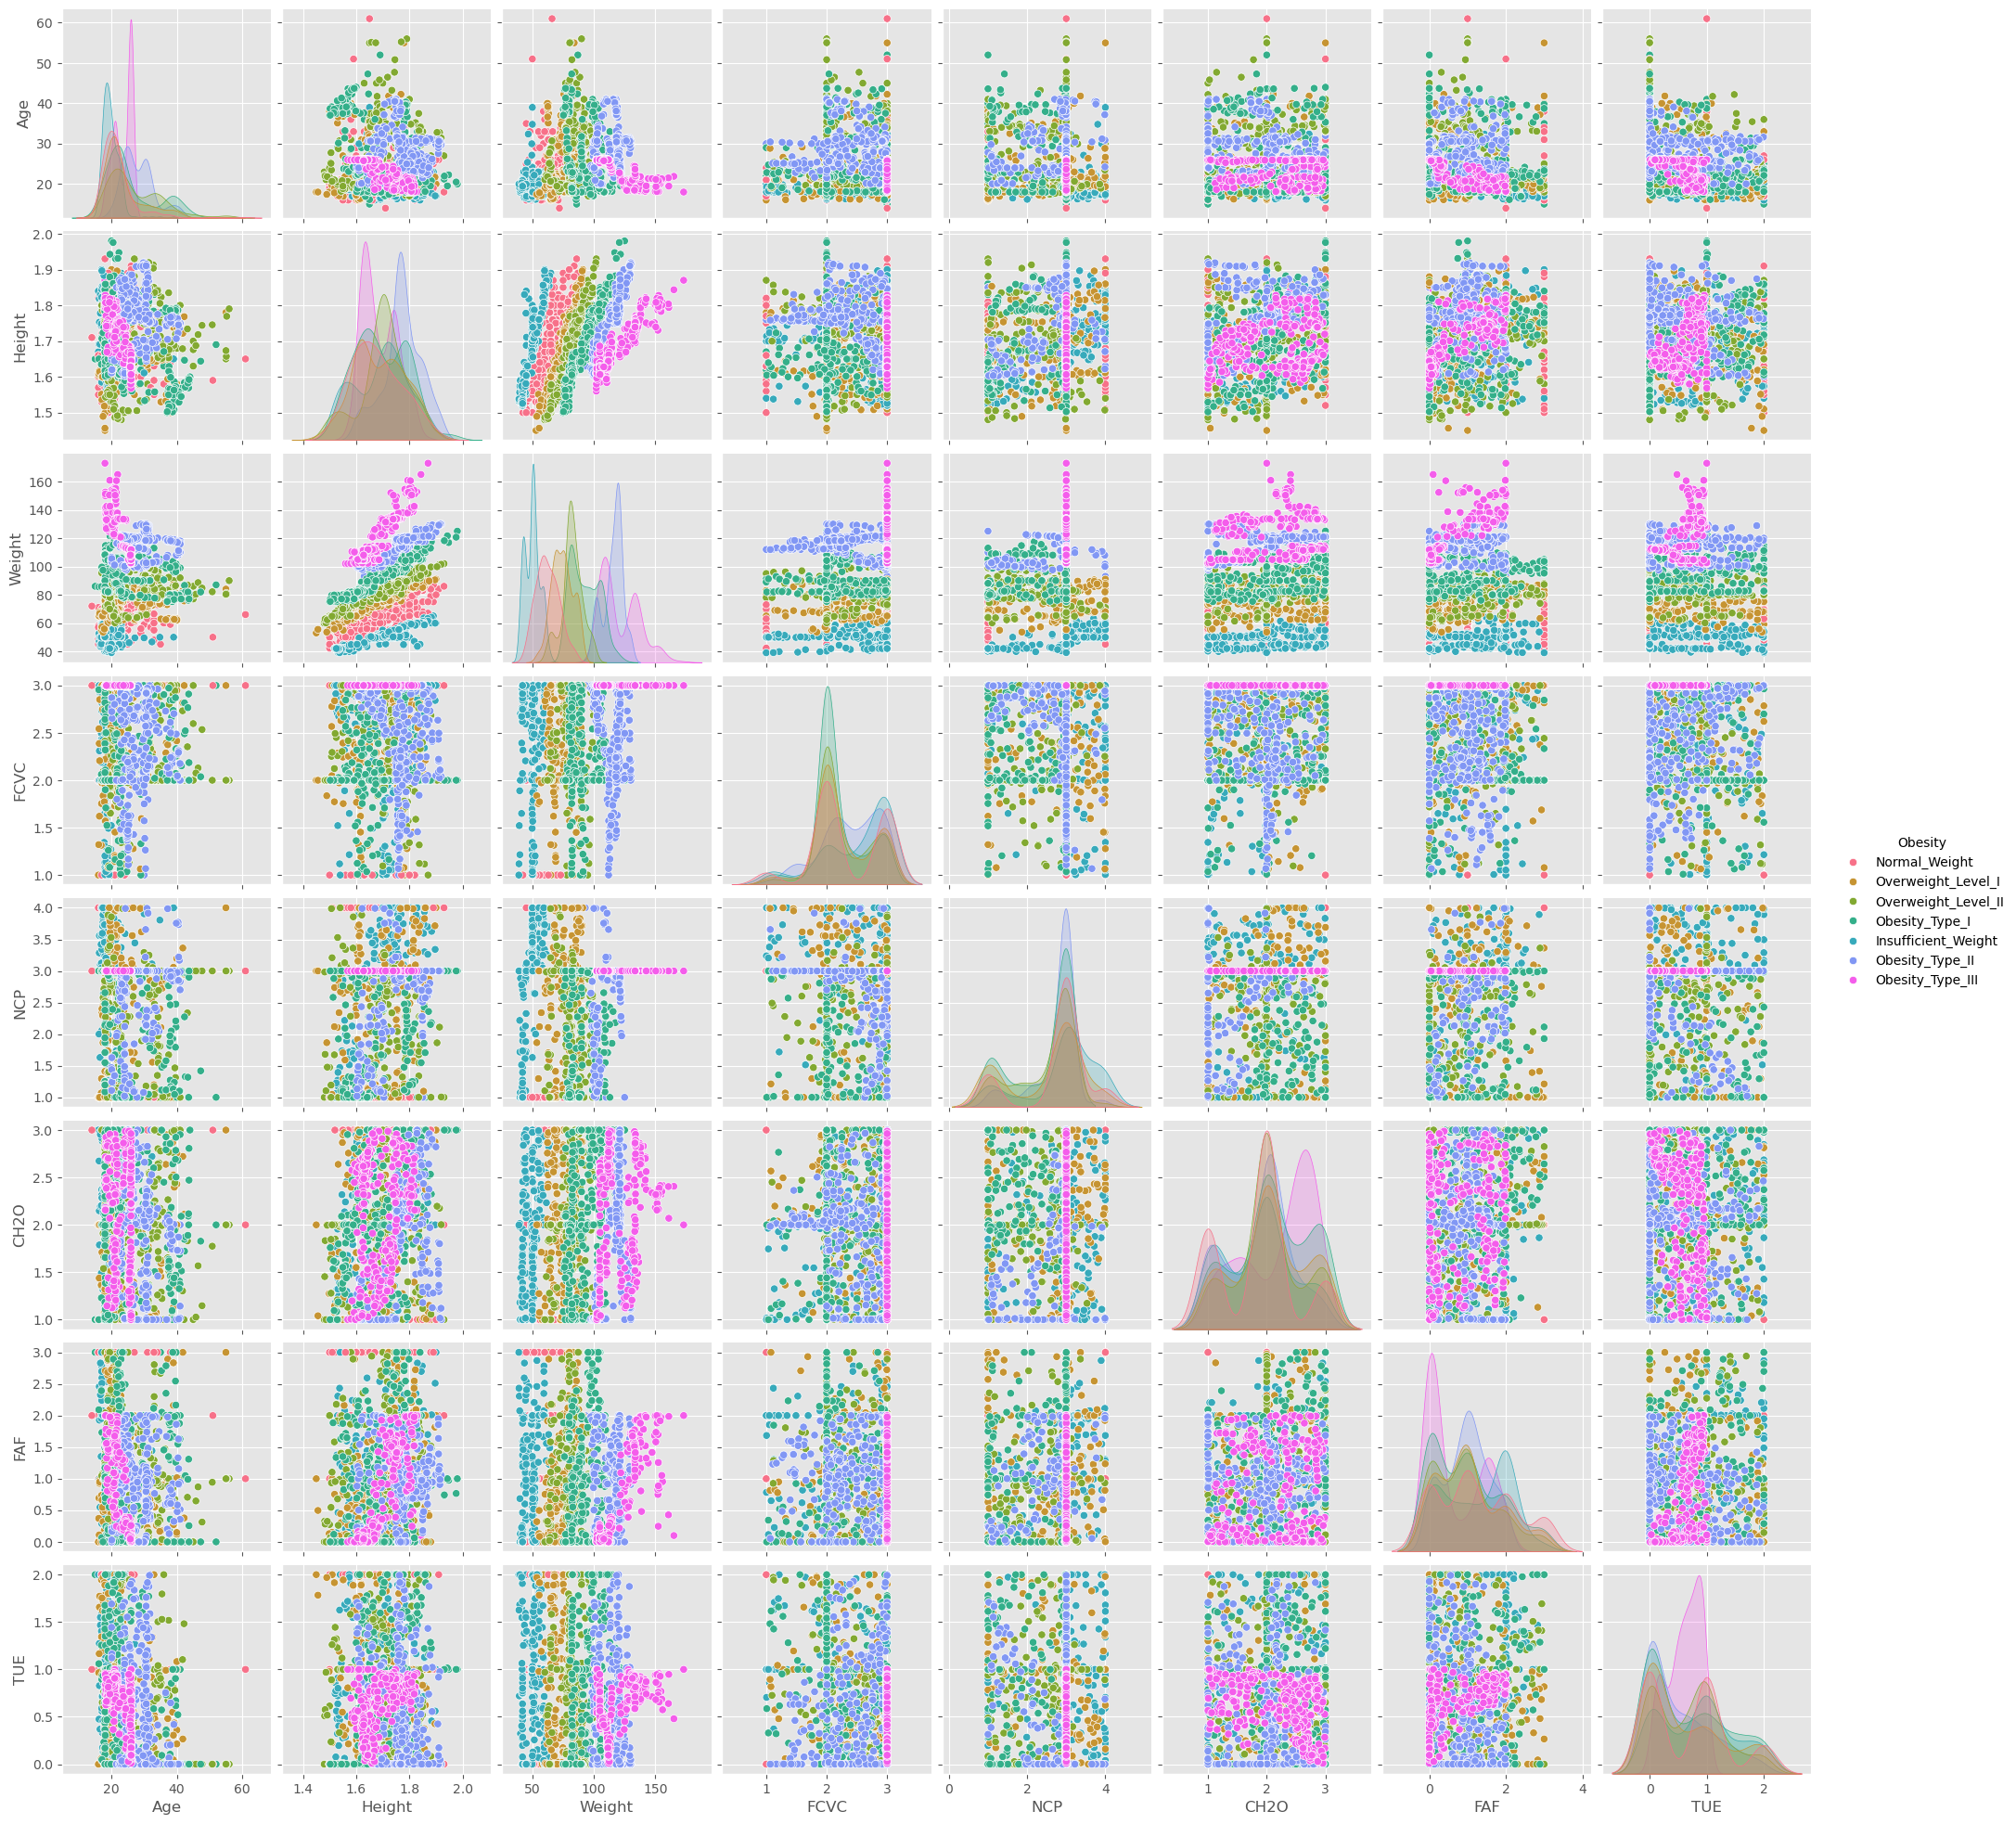

In [534]:
plot_pairplot(df, numerical_features)

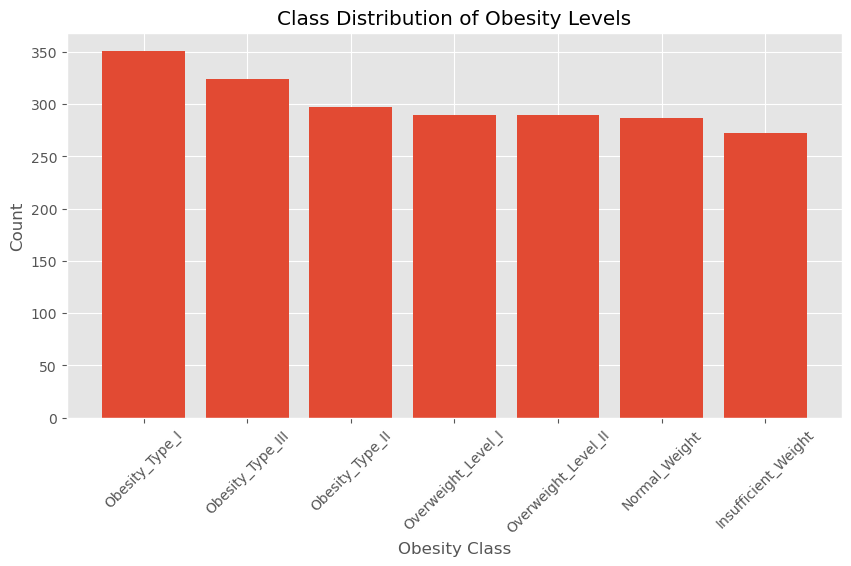

Obesity
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_I     290
Overweight_Level_II    290
Normal_Weight          287
Insufficient_Weight    272
Name: count, dtype: int64

In [536]:
# Count the occurrences of each class in the target variable
class_counts = df["Obesity"].value_counts()

# Plot class distribution
plt.figure(figsize=(10, 5))
plt.bar(class_counts.index, class_counts.values, tick_label=class_counts.index)
plt.xlabel("Obesity Class")
plt.ylabel("Count")
plt.title("Class Distribution of Obesity Levels")
plt.xticks(rotation=45)
plt.show()

# Display the class distribution
class_counts

# Data Preparation

In [539]:
# Handle missing values using median imputation
imputer = SimpleImputer(strategy='median')
df[numerical_features] = imputer.fit_transform(df[numerical_features])

In [541]:
# Encoding categorical features
label_encoders = {}
for col in categorical_features + ["Obesity"]:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le


In [545]:
# Compute Obesity Risk Factor (Multiplication of Family History & High-Caloric Food Consumption)
df['Obesity_Risk'] = df['family_history'] * df['FAVC']

In [547]:
# Standardize numerical features
scaler = StandardScaler()
df[numerical_features] = scaler.fit_transform(df[numerical_features])

In [549]:
# Separate features (X) and target variable (y)
X = df.drop(columns=["Obesity"])
y = df["Obesity"]

In [551]:
df.head()

,Gender,Age,Height,Weight,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,Obesity,BMI,Obesity_Risk
0,0,-0.522124,-0.875589,-0.862558,1,0,-0.785019,0.404153,2,0,-0.013073,0,-1.188039,0.561997,3,3,1,24.386526,0
1,0,-0.522124,-1.947599,-1.168077,1,0,1.088342,0.404153,2,1,1.618759,1,2.339750,-1.080625,2,3,1,24.238227,0
2,1,-0.206889,1.054029,-0.366090,1,0,-0.785019,0.404153,2,0,-0.013073,0,1.163820,0.561997,1,3,1,23.765432,0
3,1,0.423582,1.054029,0.015808,0,0,1.088342,0.404153,2,0,-0.013073,0,1.163820,-1.080625,1,4,5,26.851852,0
4,1,-0.364507,0.839627,0.122740,0,0,-0.785019,-2.167023,2,0,-0.013073,0,-1.188039,-1.080625,2,3,6,28.342381,0


# Feature Engineering

In [554]:
# Method 1: Recursive Feature Elimination (RFE) with Logistic Regression
estimator = LogisticRegression(random_state=42, max_iter=5000)
rfe = RFE(estimator=estimator, n_features_to_select=10)
rfe.fit(X, y)
selected_features_rfe = X.columns[rfe.support_]

In [503]:
# Method 2: SelectKBest (Univariate Selection using ANOVA F-test)
selector = SelectKBest(score_func=f_classif, k=10)
X_selected_kbest = selector.fit_transform(X, y)
selected_features_kbest = X.columns[selector.get_support()]

In [505]:
# Method 3: LassoCV (L1 Regularization-based Feature Selection)
lasso = LassoCV(cv=5, random_state=42)  # 5-fold cross-validation for best alpha
lasso.fit(X, y)
selected_features_lasso = X.columns[lasso.coef_ != 0]

In [507]:
# Final feature selection: Intersection of all methods, or union if fewer than 10 features are selected
final_selected_features = list(set(selected_features_rfe) & set(selected_features_kbest) & set(selected_features_lasso))
if len(final_selected_features) < 10:
    final_selected_features = list(set(selected_features_rfe) | set(selected_features_kbest) | set(selected_features_lasso))[:10]

print("Final Selected Features:", final_selected_features)


Final Selected Features: ['Gender', 'FCVC', 'Weight', 'FAVC', 'Obesity_Risk', 'Height', 'NCP', 'CAEC', 'CALC', 'family_history']


In [509]:
# Keep only the selected features
X_selected = X[final_selected_features]

# Split dataset into training and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=42, stratify=y)


In [511]:
# Final dataset preview
print("Final dataset preview:")
X_train.head()

Final dataset preview:


,Gender,FCVC,Weight,FAVC,Obesity_Risk,Height,NCP,CAEC,CALC,family_history
459,1,-0.785019,-0.289710,1,1,0.625225,0.404153,1,1,1
426,1,-0.785019,-0.633419,0,0,0.518024,0.404153,2,3,0
326,1,1.088342,-1.194810,1,1,-0.017981,0.404153,2,2,1
971,1,0.701607,0.040862,1,1,1.316124,1.417970,2,2,1
892,0,-0.836452,-1.119991,1,0,-1.780173,-0.444831,2,2,0


# Build the Model

## Model 1: Random Forest Model

In [515]:
### **Step 1: Build a Baseline Random Forest Model**
rf_baseline = RandomForestClassifier(random_state=42)  # Default parameters
rf_baseline.fit(X_train, y_train)  # Train model

# Predict on the test set
y_pred_baseline = rf_baseline.predict(X_test)

# Evaluate the baseline model
print("\nBaseline Random Forest Model Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_baseline):.4f}")
print(classification_report(y_test, y_pred_baseline))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_baseline))


Baseline Random Forest Model Performance:
Accuracy: 0.9314
              precision    recall  f1-score   support

           0       1.00      0.93      0.96        54
           1       0.78      0.91      0.84        58
           2       0.93      0.96      0.94        70
           3       0.98      0.95      0.97        60
           4       1.00      0.98      0.99        65
           5       0.89      0.84      0.87        58
           6       0.96      0.93      0.95        58

    accuracy                           0.93       423
   macro avg       0.94      0.93      0.93       423
weighted avg       0.94      0.93      0.93       423

Confusion Matrix:
[[50  4  0  0  0  0  0]
 [ 0 53  0  0  0  5  0]
 [ 0  0 67  0  0  1  2]
 [ 0  0  3 57  0  0  0]
 [ 0  0  0  1 64  0  0]
 [ 0  9  0  0  0 49  0]
 [ 0  2  2  0  0  0 54]]


In [352]:
### **Step 2: Cross-Validation to Evaluate Model Stability**
cv_scores = cross_val_score(rf_baseline, X_train, y_train, cv=5, scoring='accuracy')  # 5-fold cross-validation
print(f"\nCross-Validation Accuracy Scores: {cv_scores}")
print(f"Mean CV Accuracy: {np.mean(cv_scores):.4f}")  # Mean accuracy across 5 folds



Cross-Validation Accuracy Scores: [0.92899408 0.9408284  0.95266272 0.92581602 0.94658754]
Mean CV Accuracy: 0.9390


In [343]:

### **Step 3: Hyperparameter Tuning using GridSearchCV**
# Define the hyperparameter grid
# Expanded Hyperparameter Grid
param_grid = {
    'n_estimators': [50, 100, 300, 500],  
    'max_depth': [5, 10, 30, None],  
    'min_samples_split': [2, 5, 15, 30],  
    'min_samples_leaf': [1, 2, 5, 10],  
    'bootstrap': [True, False]  
}

print("\nStarting Grid Search for Hyperparameter Tuning...")
start_time = time.time()

# Perform grid search with cross-validation
grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,  # 5-fold cross-validation
    scoring='accuracy',  # Optimize for accuracy
    n_jobs=-1,  # Use all available CPU cores
    verbose=3  # Display detailed progress output
)
grid_search.fit(X_train, y_train)  # Fit GridSearchCV

end_time = time.time()
print(f"\nGrid Search Completed in {end_time - start_time:.2f} seconds")
print(f"Best Parameters: {grid_search.best_params_}")  # Show best parameters



Starting Grid Search for Hyperparameter Tuning...
Fitting 5 folds for each of 512 candidates, totalling 2560 fits
[CV 5/5] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=100;, score=0.955 total time=   0.4s
[CV 2/5] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=300;, score=0.947 total time=   0.8s
[CV 5/5] END max_depth=10, min_samples_leaf=1, min_samples_split=5, n_estimators=200;, score=0.944 total time=   0.5s
[CV 3/5] END max_depth=10, min_samples_leaf=1, min_samples_split=10, n_estimators=100;, score=0.935 total time=   0.2s
[CV 1/5] END max_depth=10, min_samples_leaf=1, min_samples_split=10, n_estimators=200;, score=0.911 total time=   0.4s
[CV 5/5] END max_depth=10, min_samples_leaf=1, min_samples_split=10, n_estimators=300;, score=0.947 total time=   0.6s
[CV 3/5] END max_depth=10, min_samples_leaf=2, min_samples_split=2, n_estimators=300;, score=0.938 total time=   0.6s
[CV 2/5] END max_depth=10, min_samples_leaf=2, min_sampl

In [345]:
### **Step 4: Evaluate the Optimized Model**
best_rf = grid_search.best_estimator_  # Retrieve the best model from GridSearchCV
y_pred_best = best_rf.predict(X_test)  # Predict with the best model

print("\nTuned Random Forest Model Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_best):.4f}")
print(classification_report(y_test, y_pred_best))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_best))


Tuned Random Forest Model Performance:
Accuracy: 0.9385
              precision    recall  f1-score   support

           0       1.00      0.93      0.96        54
           1       0.79      0.91      0.85        58
           2       0.93      0.99      0.96        70
           3       0.98      0.95      0.97        60
           4       1.00      0.98      0.99        65
           5       0.91      0.86      0.88        58
           6       0.98      0.93      0.96        58

    accuracy                           0.94       423
   macro avg       0.94      0.94      0.94       423
weighted avg       0.94      0.94      0.94       423

Confusion Matrix:
[[50  4  0  0  0  0  0]
 [ 0 53  0  0  0  5  0]
 [ 0  0 69  0  0  0  1]
 [ 0  0  3 57  0  0  0]
 [ 0  0  0  1 64  0  0]
 [ 0  8  0  0  0 50  0]
 [ 0  2  2  0  0  0 54]]


## Model 2: Gradient Boosting Model

In [348]:
### **Step 1: Baseline Gradient Boosting Model**
gb_baseline = GradientBoostingClassifier(random_state=42)  # Default parameters
gb_baseline.fit(X_train, y_train)  # Train model

# Predict on the test set
y_pred_baseline = gb_baseline.predict(X_test)

# Evaluate the baseline model
print("\nBaseline Gradient Boosting Model Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_baseline):.4f}")
print(classification_report(y_test, y_pred_baseline))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_baseline))



Baseline Gradient Boosting Model Performance:
Accuracy: 0.9574
              precision    recall  f1-score   support

           0       0.98      0.91      0.94        54
           1       0.86      0.97      0.91        58
           2       1.00      0.93      0.96        70
           3       0.95      1.00      0.98        60
           4       1.00      0.98      0.99        65
           5       0.95      0.91      0.93        58
           6       0.97      1.00      0.98        58

    accuracy                           0.96       423
   macro avg       0.96      0.96      0.96       423
weighted avg       0.96      0.96      0.96       423

Confusion Matrix:
[[49  5  0  0  0  0  0]
 [ 1 56  0  0  0  1  0]
 [ 0  0 65  2  0  2  1]
 [ 0  0  0 60  0  0  0]
 [ 0  0  0  1 64  0  0]
 [ 0  4  0  0  0 53  1]
 [ 0  0  0  0  0  0 58]]


In [350]:
### **Step 2: Cross-Validation to Evaluate Model Stability**
cv_scores = cross_val_score(gb_baseline, X_train, y_train, cv=5, scoring='accuracy')  # 5-fold cross-validation
print(f"\nCross-Validation Accuracy Scores: {cv_scores}")
print(f"Mean CV Accuracy: {np.mean(cv_scores):.4f}")  # 


Cross-Validation Accuracy Scores: [0.94674556 0.94674556 0.97928994 0.96142433 0.92878338]
Mean CV Accuracy: 0.9526


In [354]:
### **Step 3: Hyperparameter Tuning using GridSearchCV**
# Define the hyperparameter grid
param_grid = {
    'n_estimators': [100, 200, 300],  # Number of boosting stages
    'learning_rate': [0.01, 0.05, 0.1, 0.2],  # Shrinkage to prevent overfitting
    'max_depth': [3, 5, 7, 10],  # Maximum depth of individual trees
    'min_samples_split': [2, 5, 10],  # Minimum samples to split a node
    'min_samples_leaf': [1, 2, 4]  # Minimum samples in a leaf node
}

print("\nStarting Grid Search for Hyperparameter Tuning...")
start_time = time.time()

# Perform grid search with cross-validation
grid_search = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid,
    cv=5,  # 5-fold cross-validation
    scoring='accuracy',  # Optimize for accuracy
    n_jobs=-1,  # Use all available CPU cores
    verbose=3  # Display detailed progress output
)
grid_search.fit(X_train, y_train)  # Fit GridSearchCV

end_time = time.time()
print(f"\nGrid Search Completed in {end_time - start_time:.2f} seconds")
print(f"Best Parameters: {grid_search.best_params_}")  # Show best parameters


Starting Grid Search for Hyperparameter Tuning...
Fitting 5 folds for each of 432 candidates, totalling 2160 fits
[CV 3/5] END bootstrap=False, max_depth=5, min_samples_leaf=5, min_samples_split=15, n_estimators=500;, score=0.858 total time=   1.0s
[CV 2/5] END bootstrap=False, max_depth=5, min_samples_leaf=5, min_samples_split=30, n_estimators=500;, score=0.867 total time=   1.0s
[CV 3/5] END bootstrap=False, max_depth=5, min_samples_leaf=10, min_samples_split=2, n_estimators=300;, score=0.855 total time=   0.6s
[CV 5/5] END bootstrap=False, max_depth=5, min_samples_leaf=10, min_samples_split=2, n_estimators=500;, score=0.849 total time=   1.0s
[CV 3/5] END bootstrap=False, max_depth=5, min_samples_leaf=10, min_samples_split=5, n_estimators=500;, score=0.864 total time=   1.0s
[CV 1/5] END bootstrap=False, max_depth=5, min_samples_leaf=10, min_samples_split=15, n_estimators=500;, score=0.820 total time=   1.1s
[CV 3/5] END bootstrap=False, max_depth=5, min_samples_leaf=10, min_sample

In [358]:
### **Step 4: Evaluate the Optimized Model**
best_gb = grid_search.best_estimator_  # Retrieve the best model from GridSearchCV
y_pred_best = best_gb.predict(X_test)  # Predict with the best model

print("\nTuned Gradient Boosting Model Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_best):.4f}")
print(classification_report(y_test, y_pred_best))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_best))


Tuned Gradient Boosting Model Performance:
Accuracy: 0.9622
              precision    recall  f1-score   support

           0       1.00      0.89      0.94        54
           1       0.84      0.98      0.90        58
           2       0.99      0.99      0.99        70
           3       0.98      0.98      0.98        60
           4       1.00      0.98      0.99        65
           5       0.98      0.90      0.94        58
           6       0.97      1.00      0.98        58

    accuracy                           0.96       423
   macro avg       0.97      0.96      0.96       423
weighted avg       0.97      0.96      0.96       423

Confusion Matrix:
[[48  6  0  0  0  0  0]
 [ 0 57  0  0  0  1  0]
 [ 0  0 69  0  0  0  1]
 [ 0  0  1 59  0  0  0]
 [ 0  0  0  1 64  0  0]
 [ 0  5  0  0  0 52  1]
 [ 0  0  0  0  0  0 58]]


## Model 3: SVM Model

In [360]:
### **Step 1: Baseline SVM Model**
svm_baseline = SVC(random_state=42, probability=True)  # Default parameters
svm_baseline.fit(X_train, y_train)  # Train model

# Predict on the test set
y_pred_baseline = svm_baseline.predict(X_test)

# Evaluate the baseline model
print("\nBaseline SVM Model Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_baseline):.4f}")
print(classification_report(y_test, y_pred_baseline))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_baseline))



Baseline SVM Model Performance:
Accuracy: 0.9267
              precision    recall  f1-score   support

           0       0.96      0.96      0.96        54
           1       0.87      0.81      0.84        58
           2       0.97      0.96      0.96        70
           3       0.98      0.98      0.98        60
           4       1.00      0.98      0.99        65
           5       0.79      0.86      0.83        58
           6       0.90      0.91      0.91        58

    accuracy                           0.93       423
   macro avg       0.93      0.92      0.92       423
weighted avg       0.93      0.93      0.93       423

Confusion Matrix:
[[52  2  0  0  0  0  0]
 [ 2 47  0  0  0  9  0]
 [ 0  0 67  0  0  0  3]
 [ 0  0  1 59  0  0  0]
 [ 0  0  0  1 64  0  0]
 [ 0  5  0  0  0 50  3]
 [ 0  0  1  0  0  4 53]]


In [362]:
### **Step 2: Cross-Validation to Evaluate Model Stability**
cv_scores = cross_val_score(svm_baseline, X_train, y_train, cv=5, scoring='accuracy')  # 5-fold cross-validation
print(f"\nCross-Validation Accuracy Scores: {cv_scores}")
print(f"Mean CV Accuracy: {np.mean(cv_scores):.4f}")  # Mean accuracy across 5 folds



Cross-Validation Accuracy Scores: [0.8964497  0.89940828 0.91715976 0.89910979 0.93768546]
Mean CV Accuracy: 0.9100


In [364]:
### **Step 3: Hyperparameter Tuning using GridSearchCV**
# Define the hyperparameter grid
param_grid = {
    'C': [0.1, 1, 10, 100],  # Regularization parameter
    'kernel': ['linear', 'rbf', 'poly'],  # Kernel function
    'gamma': ['scale', 'auto', 0.01, 0.1, 1],  # Kernel coefficient
    'degree': [2, 3, 4]  # Only for polynomial kernel
}

print("\nStarting Grid Search for Hyperparameter Tuning...")
start_time = time.time()

# Perform grid search with cross-validation
grid_search = GridSearchCV(
    SVC(random_state=42, probability=True),
    param_grid,
    cv=5,  # 5-fold cross-validation
    scoring='accuracy',  # Optimize for accuracy
    n_jobs=-1,  # Use all available CPU cores
    verbose=3  # Display detailed progress output
)
grid_search.fit(X_train, y_train)  # Fit GridSearchCV

end_time = time.time()
print(f"\nGrid Search Completed in {end_time - start_time:.2f} seconds")
print(f"Best Parameters: {grid_search.best_params_}")  # Show best parameters



Starting Grid Search for Hyperparameter Tuning...
Fitting 5 folds for each of 180 candidates, totalling 900 fits
[CV 2/5] END learning_rate=0.05, max_depth=5, min_samples_leaf=2, min_samples_split=5, n_estimators=200;, score=0.956 total time=   6.5s
[CV 4/5] END learning_rate=0.05, max_depth=5, min_samples_leaf=2, min_samples_split=5, n_estimators=300;, score=0.955 total time=  10.0s
[CV 2/5] END learning_rate=0.05, max_depth=5, min_samples_leaf=2, min_samples_split=10, n_estimators=300;, score=0.956 total time=   9.5s
[CV 3/5] END learning_rate=0.05, max_depth=5, min_samples_leaf=4, min_samples_split=2, n_estimators=200;, score=0.976 total time=   6.6s
[CV 1/5] END learning_rate=0.05, max_depth=5, min_samples_leaf=4, min_samples_split=5, n_estimators=100;, score=0.944 total time=   3.2s
[CV 4/5] END learning_rate=0.05, max_depth=5, min_samples_leaf=4, min_samples_split=5, n_estimators=100;, score=0.961 total time=   3.4s
[CV 5/5] END learning_rate=0.05, max_depth=5, min_samples_leaf=

In [366]:
### **Step 4: Evaluate the Optimized Model**
best_svm = grid_search.best_estimator_  # Retrieve the best model from GridSearchCV
y_pred_best = best_svm.predict(X_test)  # Predict with the best model

print("\nTuned SVM Model Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_best):.4f}")
print(classification_report(y_test, y_pred_best))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_best))


Tuned SVM Model Performance:
Accuracy: 0.9669
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        54
           1       0.98      0.93      0.96        58
           2       0.97      0.99      0.98        70
           3       0.97      0.98      0.98        60
           4       1.00      0.98      0.99        65
           5       0.90      0.97      0.93        58
           6       0.98      0.91      0.95        58

    accuracy                           0.97       423
   macro avg       0.97      0.97      0.97       423
weighted avg       0.97      0.97      0.97       423

Confusion Matrix:
[[54  0  0  0  0  0  0]
 [ 2 54  0  0  0  2  0]
 [ 0  0 69  1  0  0  0]
 [ 0  0  1 59  0  0  0]
 [ 0  0  0  1 64  0  0]
 [ 0  1  0  0  0 56  1]
 [ 0  0  1  0  0  4 53]]


## Model 4: Neural Network Model

In [373]:
### **Step 1: Baseline Neural Network Model**
mlp_baseline = MLPClassifier(random_state=42, max_iter=300)  # Default parameters
mlp_baseline.fit(X_train, y_train)  # Train model

# Predict on the test set
y_pred_baseline = mlp_baseline.predict(X_test)

# Evaluate the baseline model
print("\nBaseline MLP Model Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_baseline):.4f}")
print(classification_report(y_test, y_pred_baseline))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_baseline))



Baseline MLP Model Performance:
Accuracy: 0.9598
              precision    recall  f1-score   support

           0       0.98      0.94      0.96        54
           1       0.86      0.93      0.89        58
           2       1.00      1.00      1.00        70
           3       0.98      1.00      0.99        60
           4       1.00      0.98      0.99        65
           5       0.93      0.86      0.89        58
           6       0.97      0.98      0.97        58

    accuracy                           0.96       423
   macro avg       0.96      0.96      0.96       423
weighted avg       0.96      0.96      0.96       423

Confusion Matrix:
[[51  3  0  0  0  0  0]
 [ 1 54  0  0  0  3  0]
 [ 0  0 70  0  0  0  0]
 [ 0  0  0 60  0  0  0]
 [ 0  0  0  1 64  0  0]
 [ 0  6  0  0  0 50  2]
 [ 0  0  0  0  0  1 57]]


In [375]:
### **Step 2: Cross-Validation to Evaluate Model Stability**
cv_scores = cross_val_score(mlp_baseline, X_train, y_train, cv=5, scoring='accuracy')  # 5-fold cross-validation
print(f"\nCross-Validation Accuracy Scores: {cv_scores}")
print(f"Mean CV Accuracy: {np.mean(cv_scores):.4f}")  # Mean accuracy across 5 folds



Cross-Validation Accuracy Scores: [0.94378698 0.94674556 0.95266272 0.94362018 0.95252226]
Mean CV Accuracy: 0.9479


In [381]:
### **Step 3: Hyperparameter Tuning using GridSearchCV**
# Define the hyperparameter grid
param_grid = {
    'hidden_layer_sizes': [(50,50), (100,100), (50,100,50)],  # Number of neurons in hidden layers
    'activation': ['relu', 'tanh', 'logistic'],  # Activation function
    'solver': ['adam', 'lbfgs'],  # Use 'lbfgs' for small datasets
    'alpha': [0.0001, 0.001, 0.01],  # L2 regularization term
    'learning_rate': ['constant', 'adaptive']  # Learning rate strategy
}

print("\nStarting Grid Search for Hyperparameter Tuning...")
start_time = time.time()

# Perform grid search with cross-validation
grid_search = GridSearchCV(
    MLPClassifier(random_state=42, max_iter=5000, tol=1e-4),  # Increased max_iter & added tol
    param_grid,
    cv=5,  # 5-fold cross-validation
    scoring='accuracy',  # Optimize for accuracy
    n_jobs=-1,  # Use all available CPU cores
    verbose=3  # Display detailed progress output
)
grid_search.fit(X_train, y_train)  # Fit GridSearchCV

end_time = time.time()
print(f"\nGrid Search Completed in {end_time - start_time:.2f} seconds")
print(f"Best Parameters: {grid_search.best_params_}")  # Show best parameters



Starting Grid Search for Hyperparameter Tuning...
Fitting 5 folds for each of 108 candidates, totalling 540 fits

Grid Search Completed in 372.35 seconds
Best Parameters: {'activation': 'logistic', 'alpha': 0.001, 'hidden_layer_sizes': (100, 100), 'learning_rate': 'constant', 'solver': 'adam'}


In [383]:
### **Step 4: Evaluate the Optimized Model**
best_mlp = grid_search.best_estimator_  # Retrieve the best model from GridSearchCV
y_pred_best = best_mlp.predict(X_test)  # Predict with the best model

print("\nTuned MLP Model Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_best):.4f}")
print(classification_report(y_test, y_pred_best))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_best))


Tuned MLP Model Performance:
Accuracy: 0.9764
              precision    recall  f1-score   support

           0       1.00      0.98      0.99        54
           1       0.96      0.95      0.96        58
           2       0.99      0.99      0.99        70
           3       1.00      0.98      0.99        60
           4       1.00      1.00      1.00        65
           5       0.92      0.97      0.94        58
           6       0.97      0.97      0.97        58

    accuracy                           0.98       423
   macro avg       0.98      0.98      0.98       423
weighted avg       0.98      0.98      0.98       423

Confusion Matrix:
[[53  1  0  0  0  0  0]
 [ 0 55  0  0  0  3  0]
 [ 0  0 69  0  0  0  1]
 [ 0  0  1 59  0  0  0]
 [ 0  0  0  0 65  0  0]
 [ 0  1  0  0  0 56  1]
 [ 0  0  0  0  0  2 56]]


# Model 5: Deep Neural Network with Multi-Layer Perceptron

In [420]:
### **Step 1: Define the Model Function for KerasClassifier**
def create_model(hidden_layers=(128, 64), activation='relu', dropout_rate=0.2, learning_rate=0.001):
    model = Sequential()
    
    # Input Layer (FIXED)
    model.add(Input(shape=(X_train.shape[1],)))  # This replaces `input_shape` in Dense layers

    # First Hidden Layer
    model.add(Dense(hidden_layers[0], activation=activation))
    model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))
    
    # Additional Hidden Layers
    for units in hidden_layers[1:]:
        model.add(Dense(units, activation=activation))
        model.add(BatchNormalization())
        model.add(Dropout(dropout_rate))
    
    # Output Layer
    model.add(Dense(len(np.unique(y)), activation='softmax'))  # Multi-class classification
    
    # Compile Model
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model

# Wrap model for GridSearchCV (FIXED: Using `model` instead of `build_fn`)
keras_clf = KerasClassifier(model=create_model, epochs=50, batch_size=32, verbose=0)


In [424]:

### **Step 2: Define Hyperparameter Grid**
param_grid = {
    'model__hidden_layers': [(128, 64), (256, 128, 64), (512, 256, 128)],  # Layer architectures
    'model__activation': ['relu', 'tanh'],  # Activation functions
    'model__dropout_rate': [0.2, 0.3],  # Dropout values
    'model__learning_rate': [0.001, 0.0005],  # Learning rate
}

print("\nStarting Grid Search for Hyperparameter Tuning...")
start_time = time.time()

# Perform grid search with 5-fold cross-validation
grid_search = GridSearchCV(
    estimator=keras_clf,
    param_grid=param_grid,
    cv=StratifiedKFold(n_splits=5),  # 5-Fold Cross-Validation
    scoring='accuracy',
    n_jobs=-1,
    verbose=3
)
grid_search.fit(X_train, y_train)  # Fit GridSearchCV

end_time = time.time()
print(f"\nGrid Search Completed in {end_time - start_time:.2f} seconds")
print(f"Best Parameters: {grid_search.best_params_}")  # Show best parameters



Starting Grid Search for Hyperparameter Tuning...
Fitting 5 folds for each of 24 candidates, totalling 120 fits

Grid Search Completed in 228.23 seconds
Best Parameters: {'model__activation': 'relu', 'model__dropout_rate': 0.3, 'model__hidden_layers': (256, 128, 64), 'model__learning_rate': 0.001}


In [432]:
### **Step 3: Evaluate the Optimized Model**
best_dnn = grid_search.best_estimator_
y_pred_best = best_dnn.predict(X_test)  # Predict with the best model

print("\nTuned Keras DNN Model Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_best):.4f}")
print(classification_report(y_test, y_pred_best))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_best))



Tuned Keras DNN Model Performance:
Accuracy: 0.9338
              precision    recall  f1-score   support

           0       1.00      0.94      0.97        54
           1       0.87      0.90      0.88        58
           2       0.94      0.97      0.96        70
           3       0.98      0.95      0.97        60
           4       1.00      0.98      0.99        65
           5       0.86      0.83      0.84        58
           6       0.89      0.95      0.92        58

    accuracy                           0.93       423
   macro avg       0.93      0.93      0.93       423
weighted avg       0.94      0.93      0.93       423

Confusion Matrix:
[[51  3  0  0  0  0  0]
 [ 0 52  0  0  0  6  0]
 [ 0  0 68  0  0  0  2]
 [ 0  0  3 57  0  0  0]
 [ 0  0  0  1 64  0  0]
 [ 0  5  0  0  0 48  5]
 [ 0  0  1  0  0  2 55]]


# Evaluation

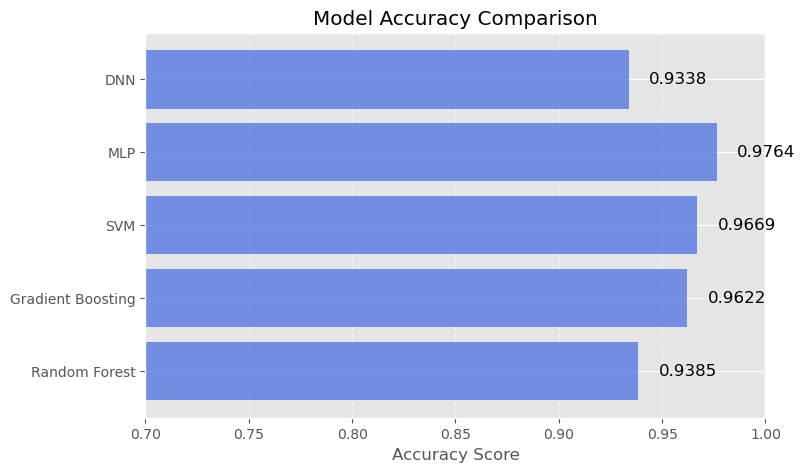

In [434]:
# Dictionary of best models and their accuracy scores
model_accuracies = {
    "Random Forest": best_rf.score(X_test, y_test),
    "Gradient Boosting": best_gb.score(X_test, y_test),
    "SVM": best_svm.score(X_test, y_test),
    "MLP": best_mlp.score(X_test, y_test),
    "DNN": best_dnn.score(X_test, y_test)
}

# Convert dictionary to sorted lists for plotting
model_names = list(model_accuracies.keys())
accuracy_scores = list(model_accuracies.values())

# Plot Accuracy Comparison
plt.figure(figsize=(8, 5))
plt.barh(model_names, accuracy_scores, color="royalblue", alpha=0.7)
plt.xlabel("Accuracy Score")
plt.title("Model Accuracy Comparison")
plt.xlim(0.7, 1.0)  # Adjust range based on expected scores
plt.grid(axis="x", linestyle="--", alpha=0.6)

# Display accuracy scores on bars
for index, value in enumerate(accuracy_scores):
    plt.text(value + 0.01, index, f"{value:.4f}", va='center', fontsize=12)

plt.show()

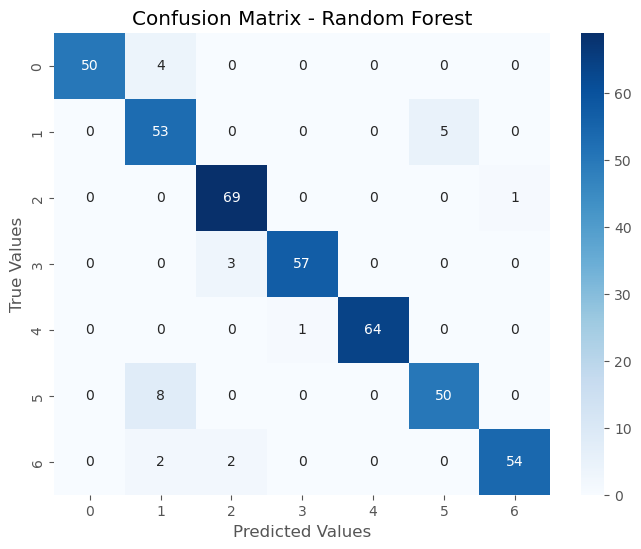

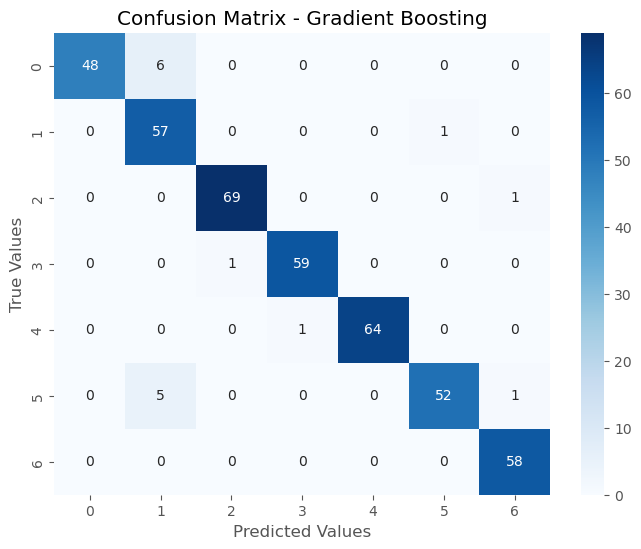

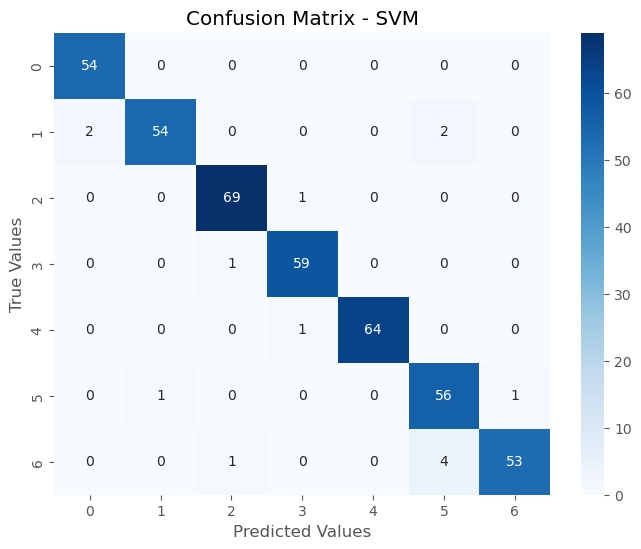

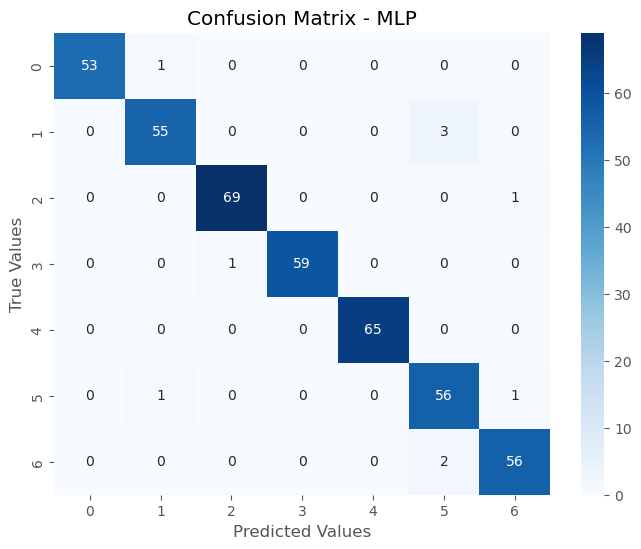

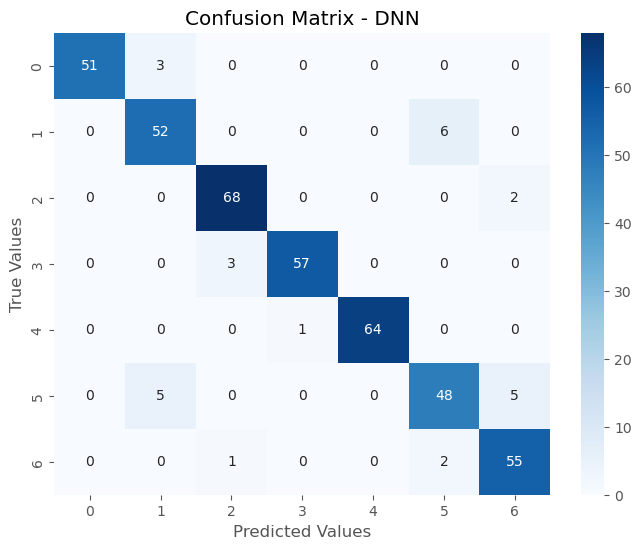

In [448]:
models = {
    "Random Forest": best_rf,
    "Gradient Boosting": best_gb,
    "SVM": best_svm,
    "MLP": best_mlp,
    "DNN": best_dnn
}

# Plot confusion matrices separately
def plot_confusion_matrix(model, model_name):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y), yticklabels=np.unique(y))
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted Values")
    plt.ylabel("True Values")
    plt.show()

# Generate confusion matrices for each model
for model_name, model in models.items():
    plot_confusion_matrix(model, model_name)

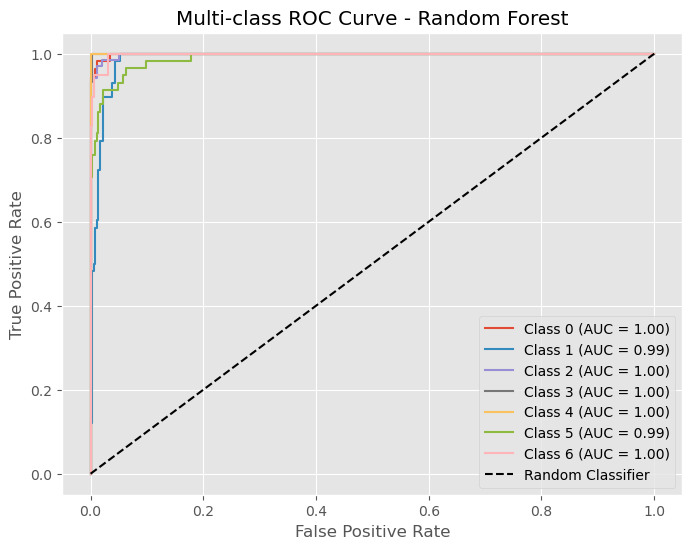

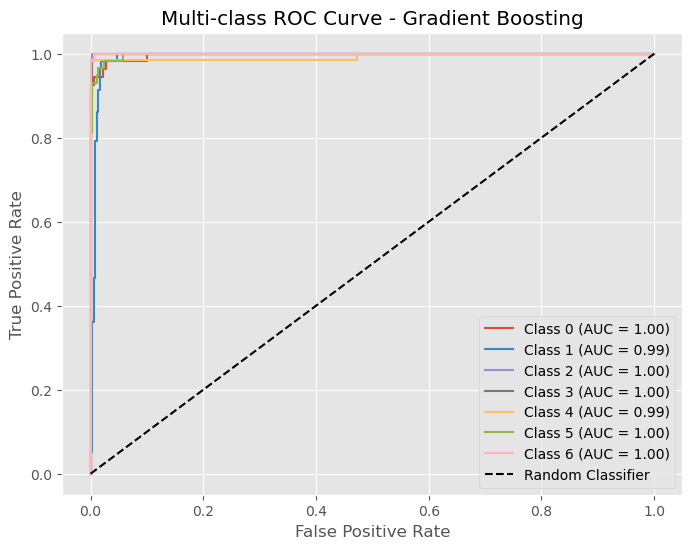

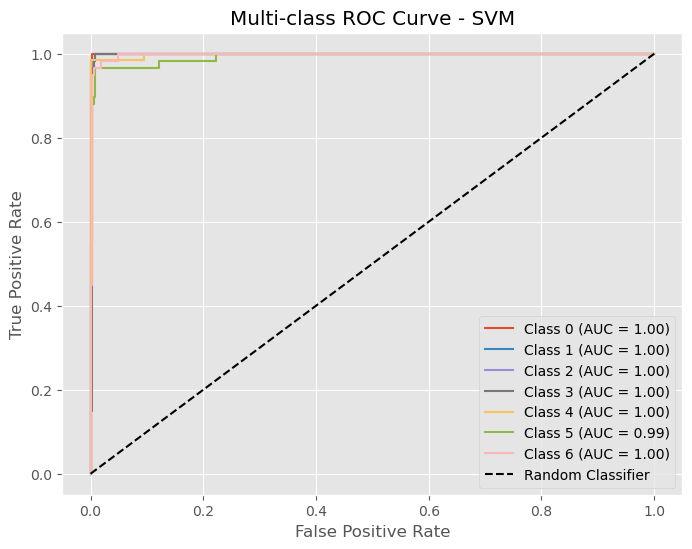

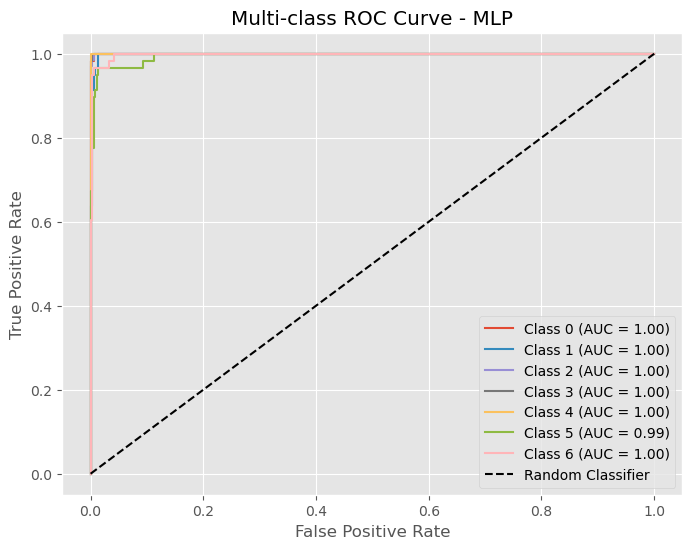

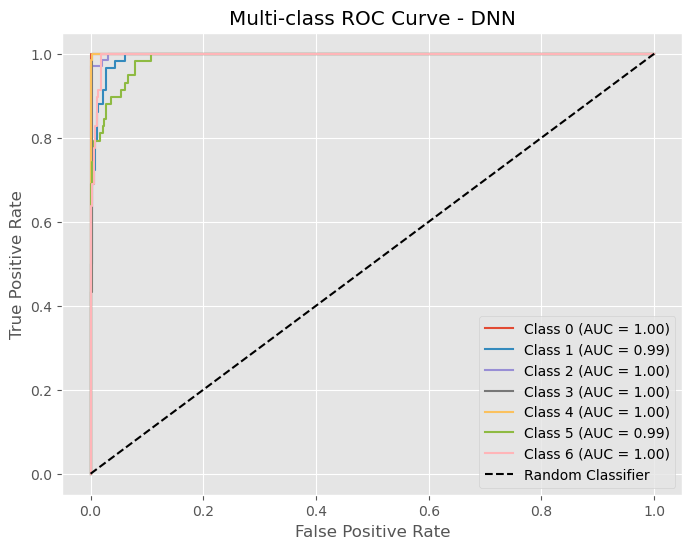

In [464]:
def plot_multiclass_roc_curve(model, model_name, X_test, y_test):

    # Get unique class labels
    classes = np.unique(y_test)
    n_classes = len(classes)

    # Convert y_test to a binary format (One-vs-Rest strategy)
    y_test_bin = label_binarize(y_test, classes=classes)

    # Create a new figure for plotting
    plt.figure(figsize=(8, 6))
    
    # Get predicted probabilities for each class
    y_prob = model.predict_proba(X_test)

    # Compute ROC curve for each class
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])  # Compute False Positive Rate & True Positive Rate
        roc_auc = auc(fpr, tpr)  # Compute Area Under the Curve (AUC)
        plt.plot(fpr, tpr, label=f'Class {classes[i]} (AUC = {roc_auc:.2f})')  # Plot ROC curve

    # Add a diagonal reference line for a random classifier
    plt.plot([0, 1], [0, 1], 'k--', label="Random Classifier")

    # Set plot labels and title
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"Multi-class ROC Curve - {model_name}")
    plt.legend(loc='lower right')
    
    # Show the plot
    plt.show()

# Generate multi-class ROC curves for each model
for model_name, model in models.items():
    plot_multiclass_roc_curve(model, model_name, X_test, y_test)

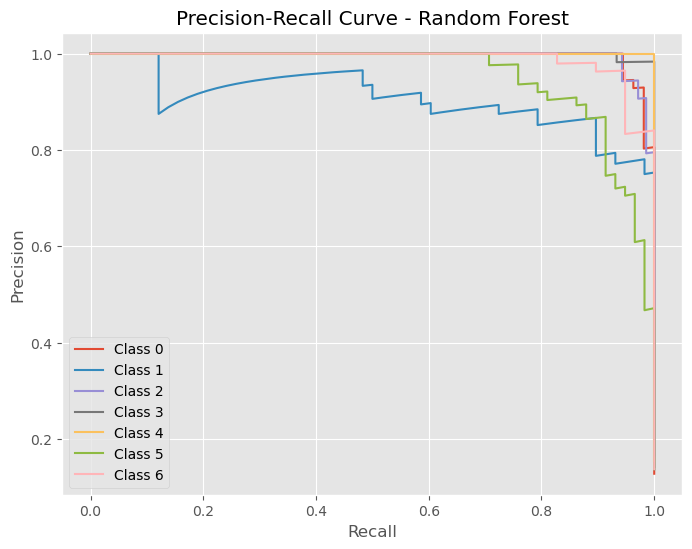

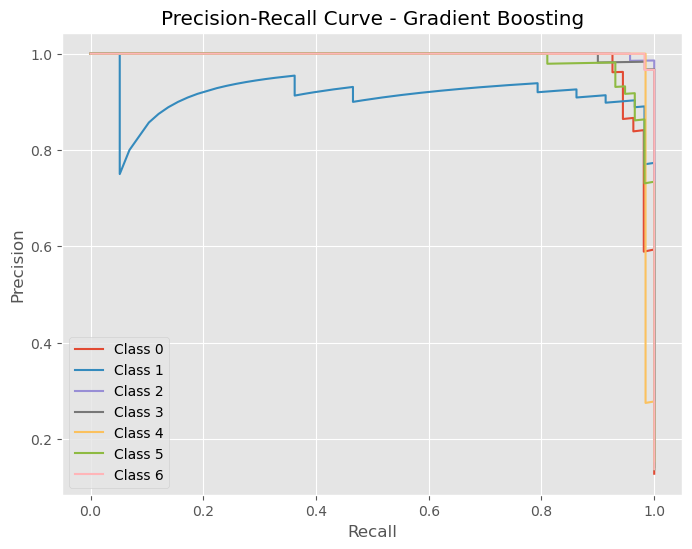

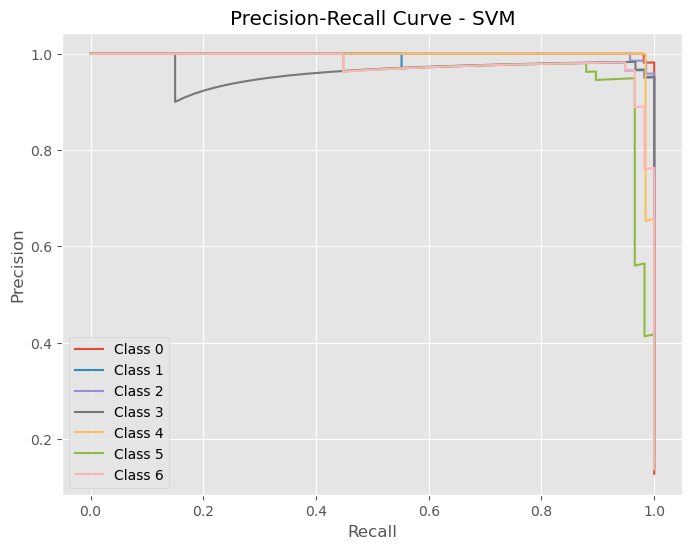

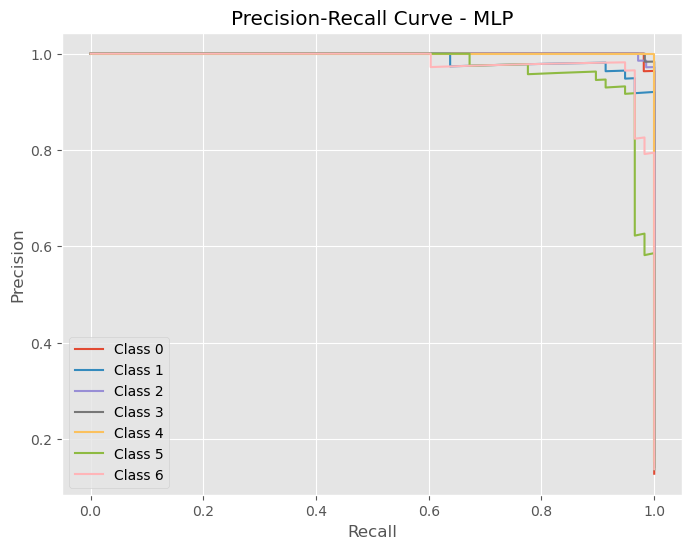

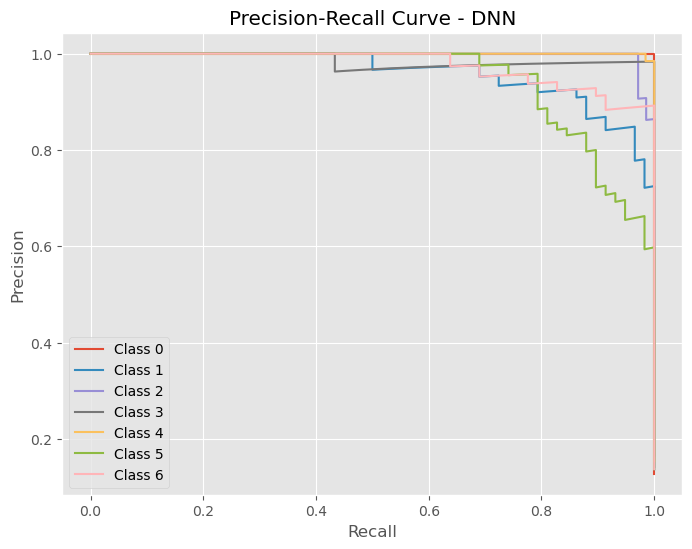

In [460]:
def plot_multiclass_pr_curve(model, model_name, X_test, y_test):

    # Get unique class labels
    classes = np.unique(y_test)
    n_classes = len(classes)

    # Convert y_test to a binary format (One-vs-Rest strategy)
    y_test_bin = label_binarize(y_test, classes=classes)

    # Create a new figure for plotting
    plt.figure(figsize=(8, 6))

    # Get predicted probabilities for each class
    y_prob = model.predict_proba(X_test)

    # Compute Precision-Recall curve for each class
    for i in range(n_classes):
        precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_prob[:, i])
        plt.plot(recall, precision, label=f'Class {classes[i]}')

    # Set plot labels and title
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision-Recall Curve - {model_name}")
    plt.legend(loc='lower left')

    # Show the plot
    plt.show()

# Generate Precision-Recall curves for each model
for model_name, model in models.items():
    plot_multiclass_pr_curve(model, model_name, X_test, y_test)

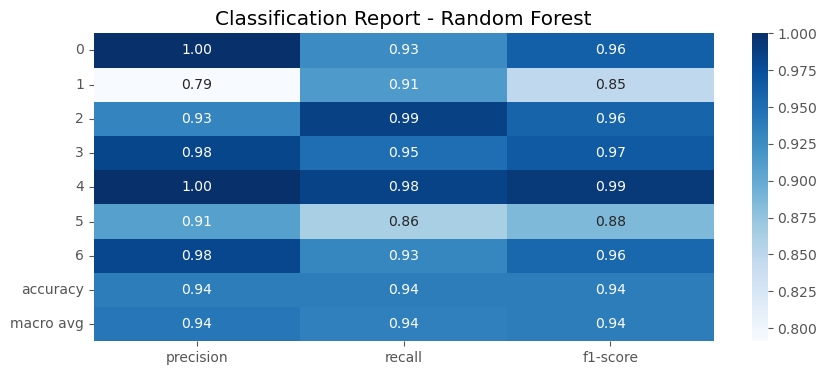

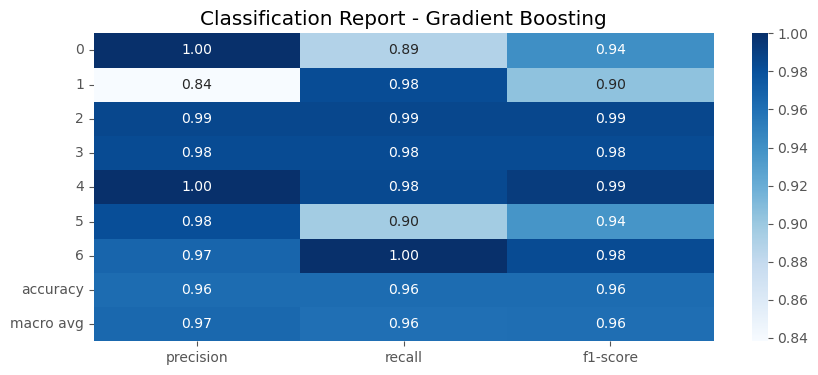

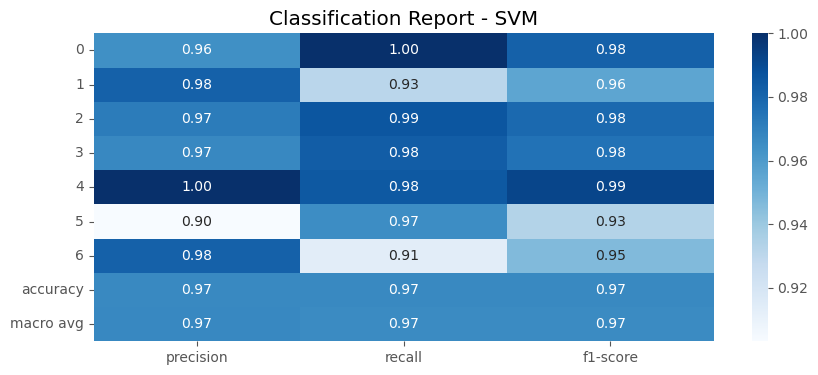

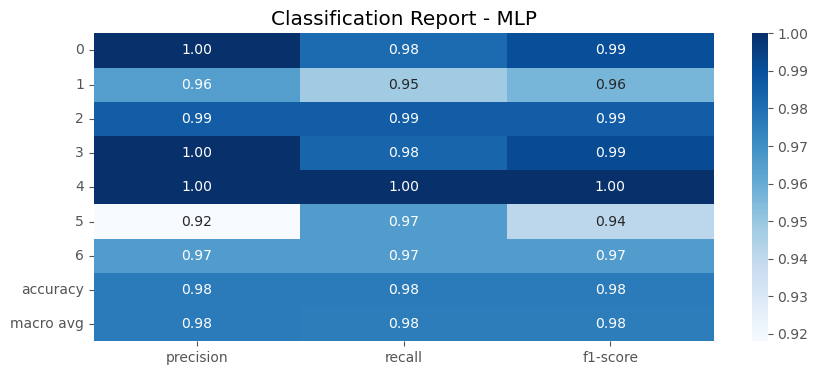

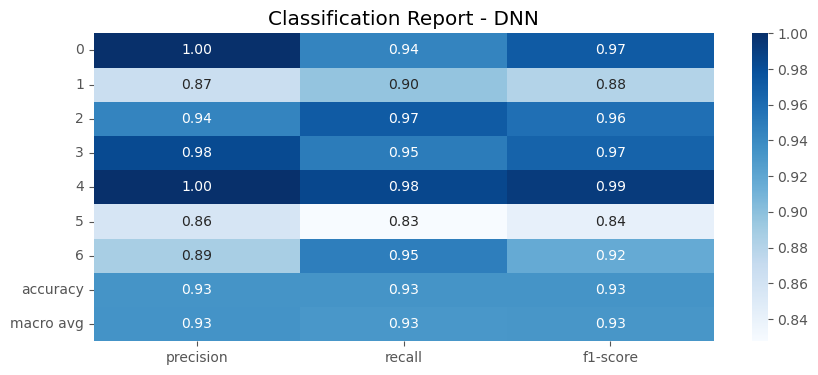

In [462]:
def plot_classification_report(model, model_name, X_test, y_test):
    
    # Get predicted labels
    y_pred = model.predict(X_test)

    # Generate classification report dictionary
    report = classification_report(y_test, y_pred, output_dict=True)
    
    # Convert to DataFrame for visualization
    df = pd.DataFrame(report).transpose()

    # Create heatmap visualization
    plt.figure(figsize=(10, 4))
    sns.heatmap(df.iloc[:-1, :-1], annot=True, cmap="Blues", fmt=".2f")  # Remove last row (accuracy)
    plt.title(f"Classification Report - {model_name}")
    
    # Show the plot
    plt.show()

# Generate Classification Report visualization for each model
for model_name, model in models.items():
    plot_classification_report(model, model_name, X_test, y_test)